[1/5] Installing and importing dependencies...

[2/5] Accessing cached Enron raw text archive...
Archive verified in local runtime environment.


Streaming from cache: 50403it [00:03, 12623.85it/s]


--> Data active. Total records ready for profiling: 50,000

[3/5] Compiling Contextual Privacy Profiling Engines...

[4/5] Executing Privacy Baseline Scan across corpus...


Scanning for sensitive entities: 100%|██████████| 50000/50000 [00:45<00:00, 1090.62it/s]



--- Structural Privacy Leakage Risk Mapping ---
Total analyzed prompt proxies: 50,000
Records containing raw structural PII: 50,000 (100.00%)

--- Entity Breakdown Summaries ---
                         count      mean        std  min  50%   95%     max
email_addresses_count  50000.0  16.90586  44.431558  1.0  5.0  61.0  1155.0
phone_numbers_count    50000.0   1.81290   4.756682  1.0  1.0   4.0   886.0
ip_addresses_count     50000.0   0.03044   0.500718  0.0  0.0   0.0    62.0
total_pii_entities     50000.0  18.74920  45.015735  2.0  7.0  63.0  1194.0

[5/5] Generating privacy density visualizations for paper introduction...


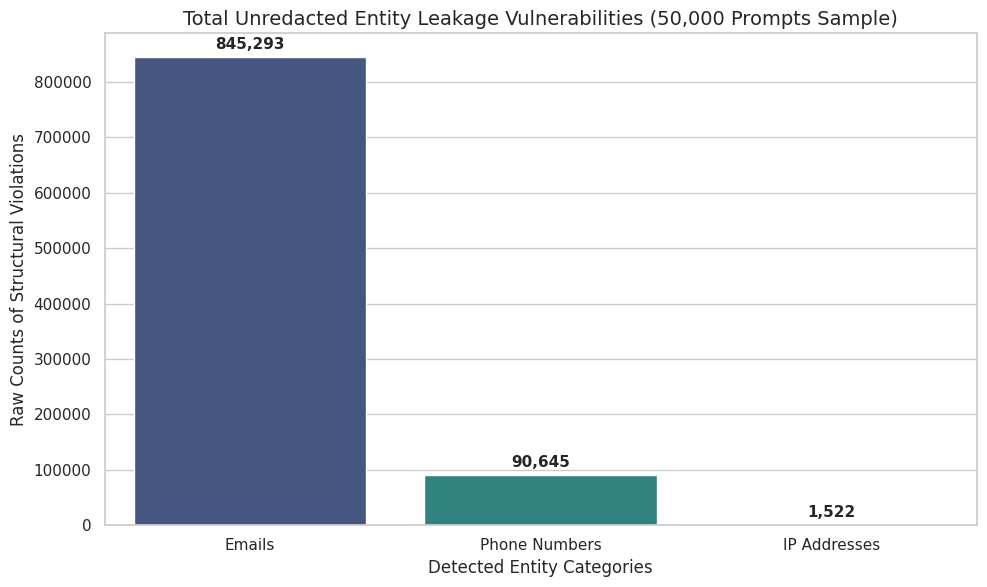


VALIDATION COMPLETE: 'enron_privacy_leakage_profile.png' successfully generated.
Baseline risk metrics logged. Ready to implement Notebook 03 Context Simulations.


In [4]:
# ==============================================================================
# 02_Privacy_Baseline_Profiling.ipynb
# Research Framework: Beyond Redaction
# Objective: Entities & Sensitive Data Density Mapping within the Target Corpus
# ==============================================================================

# 1. Environment Setup
print("[1/5] Installing and importing dependencies...")
!pip install -q pandas matplotlib seaborn tqdm

import os
import tarfile
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Set style for academic reporting
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# 2. Re-verify or Fetch Local Cache
TAR_URL = "https://www.cs.cmu.edu/~enron/enron_mail_20150507.tar.gz"
TAR_FILE = "enron_mail.tar.gz"
sample_records = []
target_limit = 50000

print("\n[2/5] Accessing cached Enron raw text archive...")

# Fallback download logic if running in a completely fresh Colab runtime session
if not os.path.exists(TAR_FILE):
    import urllib.request
    print("Archive not found in this runtime cache. Downloading raw CMU archive (~1.7 GB)...")
    try:
        urllib.request.urlretrieve(TAR_URL, TAR_FILE)
        print("--> Download Complete.")
    except Exception as e:
        print(f"--> [ERROR] Canonical mirror download failed: {e}")
else:
    print("Archive verified in local runtime environment.")

if os.path.exists(TAR_FILE):
    with tarfile.open(TAR_FILE, "r:gz") as tar:
        count = 0
        for member in tqdm(tar, desc="Streaming from cache"):
            if member.isfile() and member.name.endswith('.'):
                f = tar.extractfile(member)
                if f is not None:
                    try:
                        content = f.read().decode('utf-8', errors='ignore')
                        sample_records.append({"text": content})
                        count += 1
                    except Exception:
                        continue
            if count >= target_limit:
                break
    df = pd.DataFrame(sample_records)
    print(f"--> Data active. Total records ready for profiling: {len(df):,}")
else:
    print("[CRITICAL ERROR] Extraction aborted. Raw archive file missing.")

# 3. Define Privacy Entity Regex Profiles
print("\n[3/5] Compiling Contextual Privacy Profiling Engines...")

# Regex arrays optimized for locating structural PII footprint inside early-2000s text
PII_PROFILES = {
    'email_addresses': re.compile(r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'),
    'phone_numbers': re.compile(r'(?:\+?\d{1,3}[-.\s]?)?\(?\d{3}\)?[-.\s]?\d{3}[-.\s]?\d{4}'),
    'ip_addresses': re.compile(r'\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}\b'),
    'forwarding_headers': re.compile(r'(?i)(----------- Forwarded by|-----Original Message-----)')
}

def analyze_privacy_density(text):
    metrics = {}
    for entity_name, regex_pattern in PII_PROFILES.items():
        matches = regex_pattern.findall(text)
        metrics[f'{entity_name}_count'] = len(matches)
    return pd.Series(metrics)

# 4. Execute Leakage Baseline Profiling Loop
print("\n[4/5] Executing Privacy Baseline Scan across corpus...")
tqdm.pandas(desc="Scanning for sensitive entities")
privacy_metrics = df['text'].progress_apply(analyze_privacy_density)
df = pd.concat([df, privacy_metrics], axis=1)

# Calculate systemic totals (Excluding structural forwarding headers for pure PII assessment)
df['total_pii_entities'] = df['email_addresses_count'] + df['phone_numbers_count'] + df['ip_addresses_count']
records_with_pii = df[df['total_pii_entities'] > 0]
leakage_risk_pct = (len(records_with_pii) / len(df)) * 100

print("\n--- Structural Privacy Leakage Risk Mapping ---")
print(f"Total analyzed prompt proxies: {len(df):,}")
print(f"Records containing raw structural PII: {len(records_with_pii):,} ({leakage_risk_pct:.2f}%)")

print("\n--- Entity Breakdown Summaries ---")
# Explicitly force the computation of the 95th percentile matrix row
entity_summary = df[['email_addresses_count', 'phone_numbers_count', 'ip_addresses_count', 'total_pii_entities']].describe(percentiles=[0.25, 0.5, 0.75, 0.95]).T
print(entity_summary[['count', 'mean', 'std', 'min', '50%', '95%', 'max']])

# 5. Visualizing Risk Profile for Paper
print("\n[5/5] Generating privacy density visualizations for paper introduction...")
plt.figure(figsize=(10, 6))

categories = ['Emails', 'Phone Numbers', 'IP Addresses']
totals = [df['email_addresses_count'].sum(), df['phone_numbers_count'].sum(), df['ip_addresses_count'].sum()]

sns.barplot(x=categories, y=totals, palette="viridis", hue=categories, legend=False)
plt.title("Total Unredacted Entity Leakage Vulnerabilities (50,000 Prompts Sample)")
plt.xlabel("Detected Entity Categories")
plt.ylabel("Raw Counts of Structural Violations")

for i, total in enumerate(totals):
    plt.text(i, total + (max(totals) * 0.01), f"{total:,}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('enron_privacy_leakage_profile.png', dpi=300)
plt.show()

print("\n==============================================================================")
print("VALIDATION COMPLETE: 'enron_privacy_leakage_profile.png' successfully generated.")
print("Baseline risk metrics logged. Ready to implement Notebook 03 Context Simulations.")
print("==============================================================================")